In [2]:
import getpass
from google.colab import userdata


token = userdata.get('GithubPAT')

!git clone https://{token}@github.com/Chalhotra/ViT-Token-Economy.git
%cd ViT-Token-Economy

Cloning into 'ViT-Token-Economy'...
remote: Enumerating objects: 236, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 236 (delta 5), reused 2 (delta 2), pack-reused 221 (from 1)
Receiving objects: 100% (236/236), 6.15 MiB | 11.37 MiB/s, done.
Resolving deltas: 100% (128/128), done.
/content/ViT-Token-Economy/ViT-Token-Economy


In [3]:
# !git checkout main

In [4]:
# !git checkout -b random_drop/Vatsal

In [5]:
# !git push origin random_drop/Vatsal

In [6]:
import torch
import torch.nn as nn
import timm
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from timm.data import transforms
import PIL
from PIL import Image
import torchvision.transforms as T
import requests

In [7]:
class PrunedViT(nn.Module):
    def __init__(self, model_name='vit_tiny_patch16_224',
                 prune_layers=(2, 5, 8),
                 keep_ratios=(0.70, 0.5, 0.25)):
        super().__init__()

        self.model = timm.create_model(model_name, pretrained=True)
        self.prune_layers = prune_layers
        self.keep_ratios = keep_ratios

        assert len(prune_layers) == len(keep_ratios)

        # Determine the number of special tokens (CLS, and potentially distillation token for DeiT)
        self.num_special_tokens = self.model.num_tokens if hasattr(self.model, 'num_tokens') else 1

    def random_prune(self, x, target_k):
        """
        x: (B, N, C)
        target_k: The absolute number of patch tokens to keep.
                  This should be calculated based on the original number of patches.
        """
        B, N, C = x.shape

        # Separate special tokens (CLS, and distillation token if present) from patch tokens
        special_tokens = x[:, :self.num_special_tokens, :]      # (B, num_special_tokens, C)
        patches = x[:, self.num_special_tokens:, :]            # (B, N - num_special_tokens, C)

        num_current_patches = patches.shape[1]

        # Ensure target_k doesn't exceed current available patches or is not negative
        k = min(target_k, num_current_patches)
        k = max(0, k) # Cannot keep negative patches

        # If k is 0, just keep the special tokens (and remove all patches)
        if k == 0:
            return special_tokens

        # random indices per batch
        idx = torch.rand(B, num_current_patches, device=x.device).argsort(dim=1)
        idx = idx[:, :k]
        idx, _ = torch.sort(idx, dim=1)

        # gather patches
        patches = torch.gather(
            patches,
            1,
            idx.unsqueeze(-1).expand(-1, -1, C)
        )

        x = torch.cat([special_tokens, patches], dim=1)
        return x

    def forward_features(self, x):
        x = self.model.patch_embed(x)

        # Expand CLS token (and distillation token if present)
        if hasattr(self.model, 'cls_token'):
            cls_token = self.model.cls_token
        else:
            cls_token = None

        if hasattr(self.model, 'dist_token'):
            dist_token = self.model.dist_token
        else:
            dist_token = None

        if cls_token is not None and dist_token is not None:
            special_tokens = torch.cat((cls_token, dist_token), dim=1).expand(x.shape[0], -1, -1)
        elif cls_token is not None:
            special_tokens = cls_token.expand(x.shape[0], -1, -1)
        else:
            special_tokens = None # Should not happen for ViT/DeiT

        if special_tokens is not None:
            x = torch.cat((special_tokens, x), dim=1)

        x = x + self.model.pos_embed
        x = self.model.pos_drop(x)

        # Calculate original_num_patch_tokens based on actual num_special_tokens
        original_num_patch_tokens = x.shape[1] - self.num_special_tokens

        prune_stage = 0

        for i, blk in enumerate(self.model.blocks):
            x = blk(x)

            if i in self.prune_layers:
                # Calculate the target number of patches to keep based on the original count
                keep_ratio = self.keep_ratios[prune_stage]
                target_k_for_this_stage = int(original_num_patch_tokens * keep_ratio)
                x = self.random_prune(x, target_k_for_this_stage)
                prune_stage += 1

        x = self.model.norm(x)

        # If there's a distillation token, the head typically expects only the CLS token (index 0)
        # or sometimes both. We'll return just the CLS token (or the first special token) for the head.
        return x[:, 0]

    def forward(self, x):
        x = self.forward_features(x)
        x = self.model.head(x)
        return x

In [8]:
!pip -q install -r requirements.txt
!pip -q install -e .

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for vit-deit-baselines (pyproject.toml) ... done


In [9]:
from src.imagenet_mapping import build_imagenet100_to_1k_map
from src.models import ModelConfig, create_model, shrink_imagenet1k_head_to_imagenet100
from src.data import DataConfig, load_imagenet100_split, build_transform_for_model, apply_timm_preprocess, build_loader
from src.eval import evaluate_accuracy_latency_throughput, compute_gflops
from src.utils import get_device, num_params
import torch

In [10]:
device = get_device()
maps = build_imagenet100_to_1k_map()
ds = load_imagenet100_split(DataConfig(split='validation'))

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

data/train-00000-of-00017.parquet:   0%|          | 0.00/505M [00:00<?, ?B/s]

data/train-00001-of-00017.parquet:   0%|          | 0.00/469M [00:00<?, ?B/s]

...

data/train-00015-of-00017.parquet:   0%|          | 0.00/454M [00:00<?, ?B/s]

data/train-00016-of-00017.parquet:   0%|          | 0.00/488M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/314M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/126689 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [11]:
def run_pruned_vit(model_id: str, ds = ds, batch_size: int = 64, prune_layers: tuple = (2, 5, 8), keep_ratios: tuple = (0.70, 0.5, 0.25)):
    base_model_name = model_id.replace('pruned_', '')
    model = PrunedViT(model_name=base_model_name, prune_layers=prune_layers, keep_ratios=keep_ratios)
    shrink_imagenet1k_head_to_imagenet100(model.model, maps.new_to_old_map, num_classes=100)
    model = model.to(device).eval()
    transform = build_transform_for_model(model)
    ds_t = apply_timm_preprocess(ds, transform)
    loader = build_loader(ds_t, DataConfig(batch_size=batch_size, split='validation', shuffle=False))
    metrics = evaluate_accuracy_latency_throughput(model, loader, device)
    sample = ds_t[0]['pixel_values'].unsqueeze(0).to(device)
    gflops = compute_gflops(model, sample)
    return {
        'model': model_id,
        'params_m': num_params(model)/1e6,
        'gflops': gflops,
        **metrics
    }

def run(model_id: str, ds = ds, batch_size: int = 64, prune_layers: tuple = (2, 5, 8), keep_ratios: tuple = (0.70, 0.5, 0.25)):
    if model_id.startswith('pruned_'):
        return run_pruned_vit(model_id, ds, batch_size, prune_layers, keep_ratios)
    else:
        # Create a regular timm model
        model = create_model(ModelConfig(model_id=model_id, pretrained=True))
        # Shrink the head of the regular timm model directly
        shrink_imagenet1k_head_to_imagenet100(model, maps.new_to_old_map, num_classes=100)

    model = model.to(device).eval()
    transform = build_transform_for_model(model) # This uses model.pretrained_cfg if available
    ds_t = apply_timm_preprocess(ds, transform)
    loader = build_loader(ds_t, DataConfig(batch_size=batch_size, split='validation', shuffle=False))
    metrics = evaluate_accuracy_latency_throughput(model, loader, device)
    sample = ds_t[0]['pixel_values'].unsqueeze(0).to(device)
    gflops = compute_gflops(model, sample)
    return {
        'model': model_id,
        'params_m': num_params(model)/1e6,
        'gflops': gflops,
        **metrics
    }



In [12]:
import torch
import gc

models = [
    'pruned_vit_tiny_patch16_224',
    'pruned_vit_small_patch16_224',
    'pruned_vit_base_patch16_224',
    'pruned_deit_tiny_patch16_224',
    'pruned_deit_small_patch16_224',
    'pruned_deit_base_patch16_224'
]

results_25 = {}

for m in models:
    print(f"Running {m}...")
    results_25[m] = run(m,prune_layers=(2,5,8), keep_ratios=(0.25, 0.25, 0.25))
    print(f"Finished {m}")

    gc.collect()
    torch.cuda.empty_cache()

Running pruned_vit_tiny_patch16_224...


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_vit_tiny_patch16_224
Running pruned_vit_small_patch16_224...


...

model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_deit_small_patch16_224
Running pruned_deit_base_patch16_224...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_deit_base_patch16_224


In [13]:
from IPython.display import display, Markdown
import pandas as pd
df = pd.DataFrame(results_25).T
display(Markdown("## Vision Random Drop Experiment Results (keep rate - 25 % in each step)"))
display(df.drop('model',axis = 'columns'))

## Vision Random Drop Experiment Results (keep rate - 25 % in each step)

,params_m,gflops,acc1,latency_ms,throughput
pruned_vit_tiny_patch16_224,5.543716,0.491472,32.38,1.046805,955.287591
pruned_vit_small_patch16_224,21.704164,1.903955,66.82,1.177768,849.063529
pruned_vit_base_patch16_224,85.875556,7.491951,78.98,4.48209,223.11021
pruned_deit_tiny_patch16_224,5.543716,0.491472,71.8,0.694982,1438.88584
pruned_deit_small_patch16_224,21.704164,1.903955,83.54,1.343872,744.118632
pruned_deit_base_patch16_224,85.875556,7.491951,70.02,4.558323,219.378913


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [14]:
import torch
import gc

models = [
    'pruned_vit_tiny_patch16_224',
    'pruned_vit_small_patch16_224',
    'pruned_vit_base_patch16_224',
    'pruned_deit_tiny_patch16_224',
    'pruned_deit_small_patch16_224',
    'pruned_deit_base_patch16_224'
]

results_50 = {}

for m in models:
    print(f"Running {m}...")
    results_50[m] = run(m,prune_layers=(2,5,8), keep_ratios=(0.50, 0.50, 0.50))
    print(f"Finished {m}")

    gc.collect()
    torch.cuda.empty_cache()

df = pd.DataFrame(results_50).T
display(Markdown("## Vision Random Drop Experiment Results (keep rate - 50 % in each step)"))
display(df.drop('model',axis = 'columns'))

Running pruned_vit_tiny_patch16_224...


model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_vit_tiny_patch16_224
Running pruned_vit_small_patch16_224...


model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_vit_small_patch16_224
Running pruned_vit_base_patch16_224...


...

Finished pruned_deit_small_patch16_224
Running pruned_deit_base_patch16_224...


model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_deit_base_patch16_224


## Vision Random Drop Experiment Results (keep rate - 50 % in each step)

,params_m,gflops,acc1,latency_ms,throughput
pruned_vit_tiny_patch16_224,5.543716,0.68745,53.48,0.848707,1178.262432
pruned_vit_small_patch16_224,21.704164,2.68608,84.46,1.721966,580.7316
pruned_vit_base_patch16_224,85.875556,10.616874,89.24,6.64972,150.382278
pruned_deit_tiny_patch16_224,5.543716,0.68745,84.32,0.791751,1263.023968
pruned_deit_small_patch16_224,21.704164,2.68608,90.2,1.74276,573.802439
pruned_deit_base_patch16_224,85.875556,10.616874,90.12,6.730465,148.57815


In [15]:
import torch
import gc

models = [
    'pruned_vit_tiny_patch16_224',
    'pruned_vit_small_patch16_224',
    'pruned_vit_base_patch16_224',
    'pruned_deit_tiny_patch16_224',
    'pruned_deit_small_patch16_224',
    'pruned_deit_base_patch16_224'
]

results_70 = {}

for m in models:
    print(f"Running {m}...")
    results_70[m] = run(m,prune_layers=(2,5,8), keep_ratios=(0.70, 0.70, 0.70))
    print(f"Finished {m}")

    gc.collect()
    torch.cuda.empty_cache()

df = pd.DataFrame(results_70).T
display(Markdown("## Vision Random Drop Experiment Results (keep rate - 70 % in each step)"))
display(df.drop('model',axis = 'columns'))

Running pruned_vit_tiny_patch16_224...


model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_vit_tiny_patch16_224
Running pruned_vit_small_patch16_224...


model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_vit_small_patch16_224
Running pruned_vit_base_patch16_224...


...

Finished pruned_deit_small_patch16_224
Running pruned_deit_base_patch16_224...


model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_deit_base_patch16_224


## Vision Random Drop Experiment Results (keep rate - 70 % in each step)

,params_m,gflops,acc1,latency_ms,throughput
pruned_vit_tiny_patch16_224,5.543716,0.843433,60.64,0.984826,1015.407322
pruned_vit_small_patch16_224,21.704164,3.308587,87.68,2.229883,448.453939
pruned_vit_base_patch16_224,85.875556,13.104058,91.36,8.406282,118.958662
pruned_deit_tiny_patch16_224,5.543716,0.843433,86.42,1.177984,848.908117
pruned_deit_small_patch16_224,21.704164,3.308587,91.72,2.256567,443.151024
pruned_deit_base_patch16_224,85.875556,13.104058,92.38,8.499312,117.656588


In [16]:
import torch
import gc

models = [
    'pruned_vit_tiny_patch16_224',
    'pruned_vit_small_patch16_224',
    'pruned_vit_base_patch16_224',
    'pruned_deit_tiny_patch16_224',
    'pruned_deit_small_patch16_224',
    'pruned_deit_base_patch16_224'
]

results_90 = {}

for m in models:
    print(f"Running {m}...")
    results_90[m] = run(m,prune_layers=(2,5,8), keep_ratios=(0.90, 0.90, 0.90))
    print(f"Finished {m}")

    gc.collect()
    torch.cuda.empty_cache()

df = pd.DataFrame(results_90).T
display(Markdown("## Vision Random Drop Experiment Results (keep rate - 90 % in each step)"))
display(df.drop('model',axis = 'columns'))

Running pruned_vit_tiny_patch16_224...


model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_vit_tiny_patch16_224
Running pruned_vit_small_patch16_224...


model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_vit_small_patch16_224
Running pruned_vit_base_patch16_224...


...

Finished pruned_deit_small_patch16_224
Running pruned_deit_base_patch16_224...


model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


Finished pruned_deit_base_patch16_224


## Vision Random Drop Experiment Results (keep rate - 90 % in each step)

,params_m,gflops,acc1,latency_ms,throughput
pruned_vit_tiny_patch16_224,5.543716,0.999415,63.38,0.985379,1014.837861
pruned_vit_small_patch16_224,21.704164,3.931094,88.92,2.776232,360.20048
pruned_vit_base_patch16_224,85.875556,15.591242,92.6,10.271719,97.354685
pruned_deit_tiny_patch16_224,5.543716,0.999415,88.62,0.93779,1066.337195
pruned_deit_small_patch16_224,21.704164,3.931094,92.28,2.792789,358.065032
pruned_deit_base_patch16_224,85.875556,15.591242,93.14,10.340772,96.704582


In [17]:
# run('pruned_vit_tiny_patch16_224', prune_layers=(2,5,8), keep_ratios=(0.70, 0.5, 0.25))

In [ ]:
# run('pruned_deit_tiny_patch16_224', prune_layers=(2,5,8), keep_ratios=(0.70, 0.5, 0.25))

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
model.blocks.0.attn.attn_drop, model.blocks.1.attn.attn_drop, model.blocks.10.attn.attn_drop, model.blocks.11.attn.attn_drop, model.blocks.2.attn.attn_drop, model.blocks.3.attn.attn_drop, model.blocks.4.attn.attn_drop, model.blocks.5.attn.attn_drop, model.blocks.6.attn.attn_drop, model.blocks.7.attn.attn_drop, model.blocks.8.attn.attn_drop, model.blocks.9.attn.attn_drop, model.head_drop


{'model': 'pruned_deit_tiny_patch16_224',
 'params_m': 5.543716,
 'gflops': 0.674074752,
 'acc1': 83.08,
 'latency_ms': 0.8931354354001314,
 'throughput': 1119.6510186072646}

Visualizations

In [39]:
m = PrunedViT()

url = 'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n09468604_valley.JPEG'
response = requests.get(url, stream=True)
img = Image.open(response.raw)

transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_tensor = transform(img)
print(f"Original image tensor shape: {img_tensor.shape}")

Original image tensor shape: torch.Size([3, 224, 224])


## 3. Apply Random Pruning and Inspect Output

Here, we will explicitly call the patch embedding, add class and positional tokens, and then apply the `random_prune` method to see the effect on the token sequence shape.

In [40]:
# First, transform the 4D image tensor into the 3D token sequence expected by random_prune.
# Get patches embedded from the image tensor
embedded_patches = m.model.patch_embed(img_tensor.unsqueeze(0))

# Add the class token and positional embeddings, similar to PrunedViT's forward_features
cls_token = m.model.cls_token.expand(embedded_patches.shape[0], -1, -1)
tokens_with_cls = torch.cat((cls_token, embedded_patches), dim=1)
tokens_with_pos = tokens_with_cls + m.model.pos_embed
tokens_with_pos = m.model.pos_drop(tokens_with_pos)

# Now, apply random_prune to these correctly shaped tokens using a specific keep_ratio for demonstration
keep_ratio_for_vis = 0.25 # This is for a single pruning step demonstration  ## change here ##

# Calculate the target number of patches to keep as an integer
num_current_patches_before_pruning = tokens_with_pos.shape[1] - 1 # Exclude CLS token
target_k_for_vis = int(num_current_patches_before_pruning * keep_ratio_for_vis)

pruned_output_tokens = m.random_prune(tokens_with_pos, target_k_for_vis)

print(f"Shape after random_prune: {pruned_output_tokens.shape}")

Shape after random_prune: torch.Size([1, 50, 192])


## 4. Visualize Kept Patches

To understand which parts of the image are retained, we will denormalize the original image and highlight the patches that correspond to the tokens kept by the `random_prune` method.

Image tensor successfully denormalized and prepared for display.
Original number of patch tokens: 196
Number of patch tokens to keep: 49
Shape of kept_patch_indices: torch.Size([1, 49])


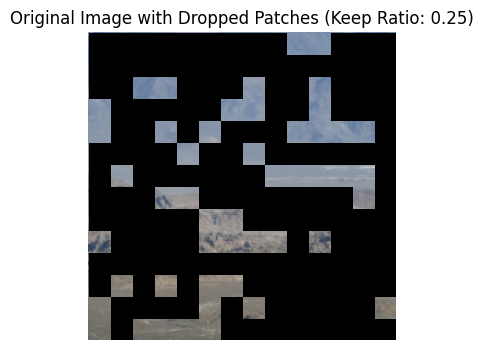

Visualization of kept and dropped patches on the original image completed.


In [41]:
# Denormalize img_tensor for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).to(img_tensor.device).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).to(img_tensor.device).view(3, 1, 1)

img_display = img_tensor * std + mean
img_display = torch.clamp(img_display, 0, 1)
img_display = img_display.permute(1, 2, 0).cpu().numpy()

print("Image tensor successfully denormalized and prepared for display.")

# Replicate patch selection logic to get indices of kept patches
# tokens_with_pos is (B, N, C), where N includes the cls token
cls_token_vis = tokens_with_pos[:, :1, :]
patch_tokens_vis = tokens_with_pos[:, 1:, :]

B, num_patches, C = patch_tokens_vis.shape
k = int(num_patches * keep_ratio_for_vis)

# Generate random indices, mirroring the random_prune method
# For visualization, we use the same `keep_ratio_for_vis`
idx = torch.rand(B, num_patches, device=patch_tokens_vis.device).argsort(dim=1)
kept_patch_indices = idx[:, :k]

print(f"Original number of patch tokens: {num_patches}")
print(f"Number of patch tokens to keep: {k}")
print(f"Shape of kept_patch_indices: {kept_patch_indices.shape}")

# Visualize the kept patches on the original image
img_size = 224 # vit_tiny_patch16_224 implies 224x224 input
patch_size = 16 # vit_tiny_patch16_224 implies 16x16 patches
num_patches_per_side = img_size // patch_size # 224 // 16 = 14

# Get kept and dropped indices
kept_indices_flat = set(kept_patch_indices[0].cpu().numpy())
all_patch_indices_flat = set(range(num_patches))
dropped_indices_flat = list(all_patch_indices_flat - kept_indices_flat)

fig, ax = plt.subplots(1, figsize=(4, 4))
ax.imshow(img_display)

# Draw dropped patches as filled black rectangles
for idx in dropped_indices_flat:
    row = idx // num_patches_per_side
    col = idx % num_patches_per_side
    x = col * patch_size
    y = row * patch_size
    rect = patches.Rectangle(
        (x, y),
        patch_size,
        patch_size,
        linewidth=0,
        edgecolor='none',
        facecolor='black'
    )
    ax.add_patch(rect)

ax.set_title(f'Original Image with Dropped Patches (Keep Ratio: {keep_ratio_for_vis})')
ax.axis('off')
plt.show()

print("Visualization of kept and dropped patches on the original image completed.")

In [42]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_random_pruning(img_tensor, model, keep_ratios=[0.9, 0.75, 0.5, 0.25]):

    device = img_tensor.device

    # ---- Prepare tokens (same as PrunedViT forward_features) ----
    embedded_patches = model.model.patch_embed(img_tensor.unsqueeze(0))

    cls_token = model.model.cls_token.expand(embedded_patches.shape[0], -1, -1)
    tokens_with_cls = torch.cat((cls_token, embedded_patches), dim=1)

    tokens_with_pos = tokens_with_cls + model.model.pos_embed
    tokens_with_pos = model.model.pos_drop(tokens_with_pos)

    patch_tokens = tokens_with_pos[:, 1:, :]
    B, num_patches, C = patch_tokens.shape

    # ---- Denormalize image ----
    mean = torch.tensor([0.485, 0.456, 0.406]).to(device).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).to(device).view(3,1,1)

    img_display = img_tensor * std + mean
    img_display = torch.clamp(img_display, 0, 1)
    img_display = img_display.permute(1,2,0).cpu().numpy()

    # ---- Patch geometry ----
    img_size = 224
    patch_size = 16
    num_patches_per_side = img_size // patch_size

    # ---- Plot ----
    fig, axes = plt.subplots(1, len(keep_ratios), figsize=(3*len(keep_ratios),3))

    if len(keep_ratios) == 1:
        axes = [axes]

    for ax, keep_ratio in zip(axes, keep_ratios):

        k = int(num_patches * keep_ratio)

        idx = torch.rand(B, num_patches, device=device).argsort(dim=1)
        kept_patch_indices = idx[:, :k]

        kept_indices_flat = set(kept_patch_indices[0].cpu().numpy())
        all_patch_indices_flat = set(range(num_patches))
        dropped_indices_flat = list(all_patch_indices_flat - kept_indices_flat)

        ax.imshow(img_display)

        # Draw dropped patches
        for patch_idx in dropped_indices_flat:
            row = patch_idx // num_patches_per_side
            col = patch_idx % num_patches_per_side

            x = col * patch_size
            y = row * patch_size

            rect = patches.Rectangle(
                (x, y),
                patch_size,
                patch_size,
                linewidth=0,
                facecolor='black'
            )
            ax.add_patch(rect)

        ax.set_title(f"Keep Ratio: {keep_ratio}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()



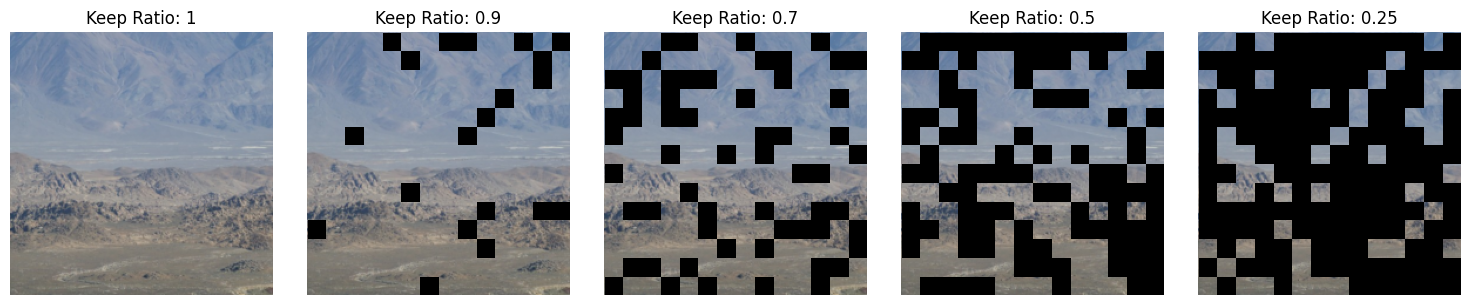

In [43]:
visualize_random_pruning(
    img_tensor,
    m,
    keep_ratios=[1,0.90, 0.70, 0.50, 0.25]
)

## 5. Test the Full PrunedViT Model

Now, let's pass the preprocessed image tensor through the full `PrunedViT` model's `forward` method to observe the final output shape after all pruning layers.

In [ ]:
model_output = m(img_tensor.unsqueeze(0))

print(f"Shape of output after full PrunedViT model forward pass: {model_output.shape}")

Shape of output after full PrunedViT model forward pass: torch.Size([1, 1000])


## 6. Extract Predicted Class from Model Output

Now, we will determine the predicted class from the `model_output` tensor. This involves finding the index with the highest logit value and mapping it to an ImageNet class label.

In [ ]:
# Get the predicted class index
predicted_class_idx = torch.argmax(model_output, dim=1).item()

# Load ImageNet class labels (if not already loaded)
# This is a common way to get ImageNet labels for timm models
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(url)
labels = response.text.split("\n")

# Get the predicted class name
predicted_class_name = labels[predicted_class_idx]

print(f"Predicted class index: {predicted_class_idx}")
print(f"Predicted class name: {predicted_class_name}")

Predicted class index: 1
Predicted class name: goldfish


In [ ]:
# !git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/02_RandomDroppingTokens_baseline.ipynb

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
# !git add .

In [ ]:
# !git commit -m "updated random_dropping baseline"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@23d18a643922.(none)')


In [ ]:
# !git push origin random_drop/Vatsal

error: src refspec random_drop/Vatsal does not match any
error: failed to push some refs to 'https://github.com/Chalhotra/ViT-Token-Economy.git'


In [ ]:
# !git branch

* main


In [ ]:
# !git checkout random_drop/Vatsal

error: Your local changes to the following files would be overwritten by checkout:
	notebooks/02_RandomDroppingTokens_baseline.ipynb
Please commit your changes or stash them before you switch branches.
Aborting


In [ ]:
# !git stash

Saved working directory and index state WIP on main: 042b39c Merge pull request #1 from Chalhotra/pipeline/chetak


In [ ]:
# !git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
# !git checkout random_drop/Vatsal

Branch 'random_drop/Vatsal' set up to track remote branch 'random_drop/Vatsal' from 'origin'.
Switched to a new branch 'random_drop/Vatsal'


In [ ]:
# !git status

On branch random_drop/Vatsal
Your branch is up to date with 'origin/random_drop/Vatsal'.

nothing to commit, working tree clean


In [ ]:
# !git push origin random_drop/Vatsal

Everything up-to-date
